# 实验3：单精度/半精度浮点运算正确性对比

## 一、实验说明

### 1.1 实验背景

在深度学习与高性能计算领域，浮点精度直接影响模型的计算准确性与推理性能。华为昇腾NPU（Neural-Network Processing Unit）为满足不同场景下的精度与性能平衡需求，同时支持FP32（单精度浮点）和FP16（半精度浮点）两种数据类型。FP16占用内存仅为FP32的一半，NPU对其计算吞吐量也显著更高，因此在推理加速和训练提速方面具有明显优势。然而，FP16的动态范围极小——其最大正数仅为65504，远低于FP32的约3.4×10³⁸，这使得FP16计算更容易发生溢出（Overflow）问题。

在实际应用中，模型从CPU/GPU迁移到昇腾NPU时，由于硬件架构、指令集以及浮点舍入模式的差异，同一算子的运算结果可能存在数值偏差。为了帮助开发人员快速定位和解决算子精度问题，CANN（Compute Architecture for Neural Networks）提供了丰富的精度配置选项和调试工具，包括精度模式设置、精度比对工具、溢出检测工具等。

本实验基于CANNLab一站式开发平台或配置有CANN Toolkit的云环境，让同学们亲自体验CANN算子的精度调用、单精度与半精度的精度差异对比，以及CPU-NPU数值一致性验证，从而具备CANN算子调用与精度配置的实践能力。


### 1.2 实验环境准备（**CANNLab在线实验跳过这一步骤**）

**软件环境：**

| 组件 | 版本要求 | 说明 |
|------|---------|------|
| 操作系统 | Ubuntu 20.04 / CentOS 7.6 及以上 | 支持昇腾驱动 |
| CANN Toolkit | 8.0.RC2 及以上版本 | 提供ATC工具、精度比对工具等 |
| Python | 3.7 及以上 | 运行精度调试脚本 |
| NumPy | 1.20+ | CPU端数值计算参考基准 |
| MindStudio（可选） | 最新版 | 集成精度比对功能 |

**硬件环境：**

| 组件 | 说明 |
|------|------|
| Atlas 300I 推理卡 / Atlas 800 训练服务器 | 提供NPU计算资源 |
| CPU | 建议8核以上，用于精度比对计算 |

**环境检查命令：**

```bash
# 检查CANN版本
cat /usr/local/Ascend/ascend-toolkit/version.cfg

# 检查NPU设备状态
npu-smi info

# 检查ATC工具可用性
atc --help

# 检查Python环境与NumPy
python3 -c "import numpy; print(numpy.__version__)"
```

## 二、实验任务

### 2.1 任务描述

本实验围绕CANN浮点精度行为展开，设置了三个递进式的实验任务：

- **任务一：FP32精度算子调用与验证。** 学习使用CANN的ATC工具将ONNX/PyTorch模型转换为OM离线模型，在FP32精度模式下执行推理，并将NPU输出与CPU参考结果进行比对，理解NPU高精度计算的数值行为。

- **任务二：FP16精度模式切换与偏差分析。** 通过配置`--precision_mode_v2`等参数切换为FP16精度模式，观察单精度与半精度之间的运算结果差异，分析误差来源与数值分布特征。

- **任务三：CPU-NPU数值一致性深度验证。** 使用CANN精度比对工具（msaccucmp.py）或自定义比对脚本，量化CPU与NPU在不同精度模式下的数值偏差，理解误差评估指标（绝对误差、相对误差、余弦相似度）的含义。


### 2.2 学习目标

通过完成本实验，同学们将具备以下能力：

1. **理解浮点精度基础理论**：掌握FP32与FP16的IEEE 754表示规范差异，理解表示范围、精度和舍入误差的概念。
2. **掌握CANN精度模式配置**：熟练使用`--precision_mode`、`--precision_mode_v2`、`--op_precision_mode`等参数进行全局与算子级精度控制。
3. **具备精度调试实践技能**：能够使用CANN精度比对工具和Dump功能定位FP16溢出和精度异常问题。
4. **建立CPU-NPU一致性分析能力**：理解NPU在混合精度计算、累加器行为、舍入模式等方面的特性，形成数值一致性验证的方法论。


## 三、任务准备

### 3.1 前置知识

#### 3.1.1 FP32与FP16的IEEE 754表示

浮点数按照IEEE 754标准进行编码，FP32和FP16的关键参数对比如下：

| 特性 | FP32（单精度） | FP16（半精度） |
|------|:-----------:|:-----------:|
| 总位数 | 32 | 16 |
| 符号位 | 1 | 1 |
| 指数位 | 8 | 5 |
| 尾数位 | 23 | 10 |
| **最大正数** | ≈ 3.4×10³⁸ | **65504** |
| 最小正数（规格化） | ≈ 1.18×10⁻³⁸ | ≈ 6.10×10⁻⁵ |
| 十进制有效位数 | 约7位 | 约3位 |
| 内存占用 | 4字节 | 2字节 |

> **关键提示**：FP16的表示上限仅为65504，这意味着在进行大规模累加操作（如LayerNorm、Softmax的Reduce操作）时极易溢出。FP32的尾数位和指数位更多，数值稳定性和精度显著优于FP16。


#### 3.1.2 CANN精度模式体系

CANN提供了丰富的精度模式参数，支持全局精度配置和单算子粒度配置：

**全局精度模式（`--precision_mode_v2`）** ：

| 取值 | 含义 |
|------|------|
| `fp16` | 强制使用float16，对于同时支持float16和float32的算子优先选择float16 |
| `origin` | 保持原始图的精度不变 |
| `cube_fp16in_fp32out` | Cube算子输入为float16、输出为float32，其他算子根据类型选择 |

**全局精度模式（`--precision_mode`，旧版本）** ：

| 取值 | 含义 |
|------|------|
| `force_fp32` | 强制使用FP32，保证最高精度 |
| `force_fp16` | 强制使用FP16，获得最高性能 |
| `allow_fp32_to_fp16` | 允许将FP32算子降为FP16 |
| `allow_mix_precision` | 使用内置策略进行混合精度处理 |
| `must_keep_origin_dtype` | 必须保持原始精度 |

**算子级精度配置（`--op_precision_mode`）** ：

通过.ini配置文件为特定算子设置精度模式，支持的模式包括：
- `high_precision`：高精度模式
- `high_performance`：高性能模式
- `enable_float_32_execution`：算子内部强制使用FP32


#### 3.1.3 CPU-NPU数值偏差根源

造成CPU与NPU运算结果偏差的主要原因包括：

1. **浮点舍入模式差异**：NPU在主流AI处理器的四种舍入模式基础上，增加了A模式和O模式，舍入规则不同会带来数值误差。
2. **累加器行为差异**：NPU的AI Core在执行FP16计算时，中间累加通常使用FP32精度。但当累加结果存回寄存器时，可能因寄存器复用导致精度丢失。
3. **计算顺序非确定性**：矩阵乘、归一化等规约运算的求和顺序在不同硬件调度下可能不同，导致浮点累加的非结合性误差被放大。
4. **算子融合与优化**：ATC模型转换时会对算子进行消除、融合、拆分等图优化，可能影响中间结果的精度。


### 3.2 实验数据准备

#### 3.2.1 准备测试模型

本实验以ResNet-50或一个简单的全连接网络作为测试模型。可任选以下方式之一：

**方式一：使用ONNX模型**

```bash
# 下载预训练的ResNet-50 ONNX模型
wget https://obs-9be7.obs.cn-east-2.myhuaweicloud.com/003_Atc_Models/resnet50/resnet50.onnx
```


**方式二：从PyTorch导出ONNX模型**

```python
import torch
import torchvision.models as models

# 加载预训练ResNet-50
model = models.resnet50(pretrained=True)
model.eval()

# 导出ONNX
dummy_input = torch.randn(1, 3, 224, 224)
torch.onnx.export(model, dummy_input, "resnet50.onnx",
                  input_names=["input"],
                  output_names=["output"],
                  opset_version=11)
```


#### 3.2.2 生成测试数据

```python
import numpy as np

# 生成FP32格式的随机测试数据
input_data = np.random.randn(1, 3, 224, 224).astype(np.float32)
input_data.tofile("input.bin")

# 保存NPY格式（供精度比对使用）
np.save("input.npy", input_data)
```


In [31]:
import numpy as np 

input_data = np.random.randn(1, 3, 224, 224).astype(np.float32)
input_data.tofile("/home/developer/experiment/lab_03/input.bin")

np.save("/home/developer/experiment/lab_03/input.npy", input_data)

## 四、任务实施

### 实验任务一：FP32精度算子调用与验证

**步骤1：模型转换（FP32精度模式）**

使用ATC工具将ONNX模型转换为昇腾OM离线模型，并明确设置为FP32精度模式：

```bash
atc --model=resnet50.onnx \
    --framework=5 \
    --output=resnet50_fp32 \
    --soc_version=Ascend310P3 \
    --input_shape="actual_input_1:1,3,224,224" \
    --precision_mode=force_fp32
```


**参数说明**：
- `--model`：输入模型文件路径
- `--framework=5`：ONNX框架标识
- `--output`：输出OM模型名称
- `--soc_version`：目标昇腾处理器型号
- `--precision_mode=force_fp32`：强制使用FP32精度模式

**步骤2：使用PyACL或AscendCL运行推理**

```python
# 推理脚本示例 (PyACL)
import acl
import numpy as np

# 初始化ACL
acl.init()

# 加载OM模型并执行推理
# (具体代码因沙箱环境版本而异，此处给出框架逻辑)

# 读取输入数据
input_data = np.fromfile("input.bin", dtype=np.float32)

# 执行推理，获取NPU输出
# npu_output = run_inference(model, input_data)

# 保存输出用于比对
np.save("npu_fp32_output.npy", npu_output)
```

In [28]:
import acl
import numpy as np 

ACL_MEM_MALLOC_HUGE_FIRST = 0
ACL_MEMCPY_HOST_TO_DEVICE = 1
ACL_MEMCPY_DEVICE_TO_HOST = 2

MODEL_PATH = "/home/developer/experiment/lab_03/resnet50_fp32.om"

def run_npu_inference(input_data):
    # 1. ACL初始化
    ret = acl.init()
    assert ret == 0, "ACL初始化失败"

    # 2. 打开设备并创建Context
    device_id = 0
    ret = acl.rt.set_device(device_id)
    context, ret = acl.rt.create_context(device_id)
    assert ret == 0, "创建Context失败"

    # 3. 加载模型
    model_id, ret = acl.mdl.load_from_file(MODEL_PATH)
    model_desc = acl.mdl.create_desc()
    ret = acl.mdl.get_desc(model_desc, model_id)

    # 4. 创建输入数据集
    input_size = input_data.nbytes
    input_buffer, ret = acl.rt.malloc(input_size, ACL_MEM_MALLOC_HUGE_FIRST)
    src_ptr = acl.util.bytes_to_ptr(input_data.tobytes())
    ret = acl.rt.memcpy(input_buffer, input_size,
                        src_ptr, input_size,
                        ACL_MEMCPY_HOST_TO_DEVICE)

    input_dataset = acl.mdl.create_dataset()
    input_data_buffer = acl.create_data_buffer(input_buffer, input_size)
    _, ret = acl.mdl.add_dataset_buffer(input_dataset, input_data_buffer)

    # 5. 准备输出数据集
    output_size = acl.mdl.get_output_size_by_index(model_desc, 0)
    output_buffer, ret = acl.rt.malloc(output_size, ACL_MEM_MALLOC_HUGE_FIRST)
    output_dataset = acl.mdl.create_dataset()
    output_data_buffer = acl.create_data_buffer(output_buffer, output_size)
    _, ret = acl.mdl.add_dataset_buffer(output_dataset, output_data_buffer)

    # 6. 执行推理
    ret = acl.mdl.execute(model_id, input_dataset, output_dataset)

    # 7. 获取输出结果
    result_buffer, ret = acl.rt.malloc_host(output_size)
    ret = acl.rt.memcpy(result_buffer, output_size, output_buffer, output_size, ACL_MEMCPY_DEVICE_TO_HOST)

    result_bytes = acl.util.ptr_to_bytes(result_buffer, output_size)
    result = np.frombuffer(result_bytes, dtype=np.float32)
        
    # 8. 释放资源
    acl.mdl.destroy_dataset(output_dataset)
    acl.mdl.destroy_dataset(input_dataset)
    acl.rt.free(output_buffer)
    acl.rt.free(input_buffer)
    acl.destroy_data_buffer(input_data_buffer)
    acl.destroy_data_buffer(output_data_buffer)
    acl.mdl.destroy_desc(model_desc)
    acl.mdl.unload(model_id)
    acl.rt.destroy_context(context)
    acl.rt.reset_device(device_id)
    acl.finalize()

    return result

In [37]:
input_data = np.random.randn(16, 3, 224, 224).astype(np.float32)

npu_output = run_npu_inference(input_data[0])

np.save("/home/developer/experiment/lab_03/npu_fp32_output.npy", npu_output)

In [38]:
import onnxruntime as ort 

MODEL_ONNX_PATH = "/home/developer/experiment/lab_03/resnet50.onnx"

session = ort.InferenceSession(MODEL_ONNX_PATH)
cpu_output = session.run(None, {"actual_input_1": input_data})[0][0]
print(cpu_output.shape, npu_output.shape)
np.save("/home/developer/experiment/lab_03/cpu_output.npy", cpu_output)

(1000,) (1000,)


**步骤3：CPU-NPU精度比对**

```python
import numpy as np

cpu_output = np.load("cpu_output.npy")
npu_output = np.load("npu_fp32_output.npy")

# 计算精度指标
abs_error = np.abs(cpu_output - npu_output)
max_abs_error = np.max(abs_error)
mean_abs_error = np.mean(abs_error)
rel_error = np.abs(cpu_output - npu_output) / (np.abs(cpu_output) + 1e-8)
max_rel_error = np.max(rel_error)

# 余弦相似度
cos_sim = np.dot(cpu_output.flatten(), npu_output.flatten()) / (
    np.linalg.norm(cpu_output.flatten()) * np.linalg.norm(npu_output.flatten()) + 1e-8
)

print(f"=== FP32精度模式：CPU vs NPU ===")
print(f"最大绝对误差: {max_abs_error:.6e}")
print(f"平均绝对误差: {mean_abs_error:.6e}")
print(f"最大相对误差: {max_rel_error:.6e}")
print(f"余弦相似度:   {cos_sim:.8f}")

# 判断是否通过
threshold = 1e-5
if max_rel_error < threshold:
    print(f"✅ FP32精度验证通过（误差 < {threshold}）")
else:
    print(f"⚠️ FP32精度偏差较大，请检查环境配置")
```

**预期结果**：FP32精度模式下，CPU与NPU的输出应高度一致，余弦相似度接近1.0（>0.9999），最大相对误差在10⁻⁵量级以内。

In [45]:
# 计算精度指标
npu_output = npu_output[0:1000]
abs_error = np.abs(cpu_output - npu_output)
max_abs_error = np.max(abs_error)
mean_abs_error = np.mean(abs_error)
rel_error = np.abs(cpu_output - npu_output) / (np.abs(cpu_output) + 1e-8)
max_rel_error = np.max(rel_error)

# 余弦相似度
cos_sim = np.dot(cpu_output.flatten(), npu_output.flatten()) / (
    np.linalg.norm(cpu_output.flatten()) * np.linalg.norm(npu_output.flatten()) + 1e-8
)

print(f"=== FP32精度模式：CPU vs NPU ===")
print(f"最大绝对误差: {max_abs_error:.6e}")
print(f"平均绝对误差: {mean_abs_error:.6e}")
print(f"最大相对误差: {max_rel_error:.6e}")
print(f"余弦相似度:   {cos_sim:.8f}")

# 判断是否通过
threshold = 1e-5
if max_rel_error < threshold:
    print(f"✅ FP32精度验证通过（误差 < {threshold}）")
else:
    print(f"⚠️ FP32精度偏差较大，请检查环境配置")

=== FP32精度模式：CPU vs NPU ===
最大绝对误差: 9.001255e-03
平均绝对误差: 1.261689e-03
最大相对误差: 5.617335e-01
余弦相似度:   0.99999950
⚠️ FP32精度偏差较大，请检查环境配置


### 实验任务二：FP16精度模式切换与偏差分析

**步骤1：模型转换（FP16精度模式）**

```bash
atc --model=resnet50.onnx \
    --framework=5 \
    --output=resnet50_fp16 \
    --soc_version=Ascend310P3 \
    --input_shape="actual_input_1:1,3,224,224" \
    --precision_mode_v2=fp16
```

这里使用`--precision_mode_v2=fp16`，对所有同时支持FP32和FP16的算子强制使用FP16精度。

**步骤2：FP16模式下执行推理**

与任务一步骤2相同，加载resnet50_fp16.om模型并执行推理，保存NPU FP16输出。


In [46]:
import acl
import numpy as np 

ACL_MEM_MALLOC_HUGE_FIRST = 0
ACL_MEMCPY_HOST_TO_DEVICE = 1
ACL_MEMCPY_DEVICE_TO_HOST = 2

MODEL_PATH = "/home/developer/experiment/lab_03/resnet50_fp16.om"

def run_npu_inference(input_data):
    # 1. ACL初始化
    ret = acl.init()
    assert ret == 0, "ACL初始化失败"

    # 2. 打开设备并创建Context
    device_id = 0
    ret = acl.rt.set_device(device_id)
    context, ret = acl.rt.create_context(device_id)
    assert ret == 0, "创建Context失败"

    # 3. 加载模型
    model_id, ret = acl.mdl.load_from_file(MODEL_PATH)
    model_desc = acl.mdl.create_desc()
    ret = acl.mdl.get_desc(model_desc, model_id)

    # 4. 创建输入数据集
    input_size = input_data.nbytes
    input_buffer, ret = acl.rt.malloc(input_size, ACL_MEM_MALLOC_HUGE_FIRST)
    src_ptr = acl.util.bytes_to_ptr(input_data.tobytes())
    ret = acl.rt.memcpy(input_buffer, input_size,
                        src_ptr, input_size,
                        ACL_MEMCPY_HOST_TO_DEVICE)

    input_dataset = acl.mdl.create_dataset()
    input_data_buffer = acl.create_data_buffer(input_buffer, input_size)
    _, ret = acl.mdl.add_dataset_buffer(input_dataset, input_data_buffer)

    # 5. 准备输出数据集
    output_size = acl.mdl.get_output_size_by_index(model_desc, 0)
    output_buffer, ret = acl.rt.malloc(output_size, ACL_MEM_MALLOC_HUGE_FIRST)
    output_dataset = acl.mdl.create_dataset()
    output_data_buffer = acl.create_data_buffer(output_buffer, output_size)
    _, ret = acl.mdl.add_dataset_buffer(output_dataset, output_data_buffer)

    # 6. 执行推理
    ret = acl.mdl.execute(model_id, input_dataset, output_dataset)

    # 7. 获取输出结果
    result_buffer, ret = acl.rt.malloc_host(output_size)
    ret = acl.rt.memcpy(result_buffer, output_size, output_buffer, output_size, ACL_MEMCPY_DEVICE_TO_HOST)

    result_bytes = acl.util.ptr_to_bytes(result_buffer, output_size)
    result = np.frombuffer(result_bytes, dtype=np.float32)
        
    # 8. 释放资源
    acl.mdl.destroy_dataset(output_dataset)
    acl.mdl.destroy_dataset(input_dataset)
    acl.rt.free(output_buffer)
    acl.rt.free(input_buffer)
    acl.destroy_data_buffer(input_data_buffer)
    acl.destroy_data_buffer(output_data_buffer)
    acl.mdl.destroy_desc(model_desc)
    acl.mdl.unload(model_id)
    acl.rt.destroy_context(context)
    acl.rt.reset_device(device_id)
    acl.finalize()

    return result

In [47]:
npu_fp16_output = run_npu_inference(input_data[0])
np.save("/home/developer/experiment/lab_03/npu_fp16_output.npy", npu_fp16_output)

**步骤3：FP16 vs FP32精度对比分析**

```python
import numpy as np

cpu_output = np.load("cpu_output.npy")       # CPU FP32参考
npu_fp32 = np.load("npu_fp32_output.npy")    # NPU FP32输出
npu_fp16 = np.load("npu_fp16_output.npy")    # NPU FP16输出

def calc_metrics(ref, target, label):
    abs_error = np.abs(ref - target)
    rel_error = np.abs(ref - target) / (np.abs(ref) + 1e-8)
    cos_sim = np.dot(ref.flatten(), target.flatten()) / (
        np.linalg.norm(ref.flatten()) * np.linalg.norm(target.flatten()) + 1e-8
    )
    print(f"\n=== {label} ===")
    print(f"最大绝对误差: {np.max(abs_error):.6e}")
    print(f"平均绝对误差: {np.mean(abs_error):.6e}")
    print(f"最大相对误差: {np.max(rel_error):.6e}")
    print(f"余弦相似度:   {cos_sim:.8f}")

# 1. NPU FP32 vs CPU（任务一的基准）
calc_metrics(cpu_output, npu_fp32, "NPU_FP32 vs CPU")

# 2. NPU FP16 vs CPU（降精度后的偏差）
calc_metrics(cpu_output, npu_fp16, "NPU_FP16 vs CPU")

# 3. NPU FP16 vs NPU FP32（精度模式之间的差异）
calc_metrics(npu_fp32, npu_fp16, "NPU_FP16 vs NPU_FP32")
```

In [48]:
def calc_metrics(ref, target, label):
    abs_error = np.abs(ref - target)
    rel_error = np.abs(ref - target) / (np.abs(ref) + 1e-8)
    cos_sim = np.dot(ref.flatten(), target.flatten()) / (
        np.linalg.norm(ref.flatten()) * np.linalg.norm(target.flatten()) + 1e-8
    )
    print(f"\n=== {label} ===")
    print(f"最大绝对误差: {np.max(abs_error):.6e}")
    print(f"平均绝对误差: {np.mean(abs_error):.6e}")
    print(f"最大相对误差: {np.max(rel_error):.6e}")
    print(f"余弦相似度:   {cos_sim:.8f}")

calc_metrics(cpu_output, npu_output, "NPU_FP32 vs CPU")

# 2. NPU FP16 vs CPU（降精度后的偏差）
calc_metrics(cpu_output, npu_fp16_output, "NPU_FP16 vs CPU")

# 3. NPU FP16 vs NPU FP32（精度模式之间的差异）
calc_metrics(npu_output, npu_fp16_output, "NPU_FP16 vs NPU_FP32")


=== NPU_FP32 vs CPU ===
最大绝对误差: 9.001255e-03
平均绝对误差: 1.261689e-03
最大相对误差: 5.617335e-01
余弦相似度:   0.99999950

=== NPU_FP16 vs CPU ===
最大绝对误差: 9.001255e-03
平均绝对误差: 1.261689e-03
最大相对误差: 5.617335e-01
余弦相似度:   0.99999950

=== NPU_FP16 vs NPU_FP32 ===
最大绝对误差: 0.000000e+00
平均绝对误差: 0.000000e+00
最大相对误差: 0.000000e+00
余弦相似度:   1.00000008


**步骤4：偏差分布可视化**

```python
import matplotlib.pyplot as plt

errors_fp16 = np.abs(cpu_output.flatten() - npu_fp16.flatten())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 误差分布直方图
axes[0].hist(errors_fp16, bins=100, color='orange', edgecolor='black', alpha=0.7)
axes[0].set_xlabel("Absolute Error")
axes[0].set_ylabel("Frequency")
axes[0].set_title("FP16 vs CPU: Error Distribution")
axes[0].axvline(np.mean(errors_fp16), color='red', linestyle='--', label=f"Mean={np.mean(errors_fp16):.2e}")
axes[0].legend()

# 散点图：CPU vs FP16
axes[1].scatter(cpu_output.flatten()[:500], npu_fp16.flatten()[:500], s=2, alpha=0.5)
axes[1].plot([cpu_output.min(), cpu_output.max()], [cpu_output.min(), cpu_output.max()], 'r--', alpha=0.5)
axes[1].set_xlabel("CPU Output")
axes[1].set_ylabel("NPU FP16 Output")
axes[1].set_title("CPU vs NPU FP16: Scatter Plot")

plt.tight_layout()
plt.savefig("fp16_error_analysis.png", dpi=150)
plt.show()
```

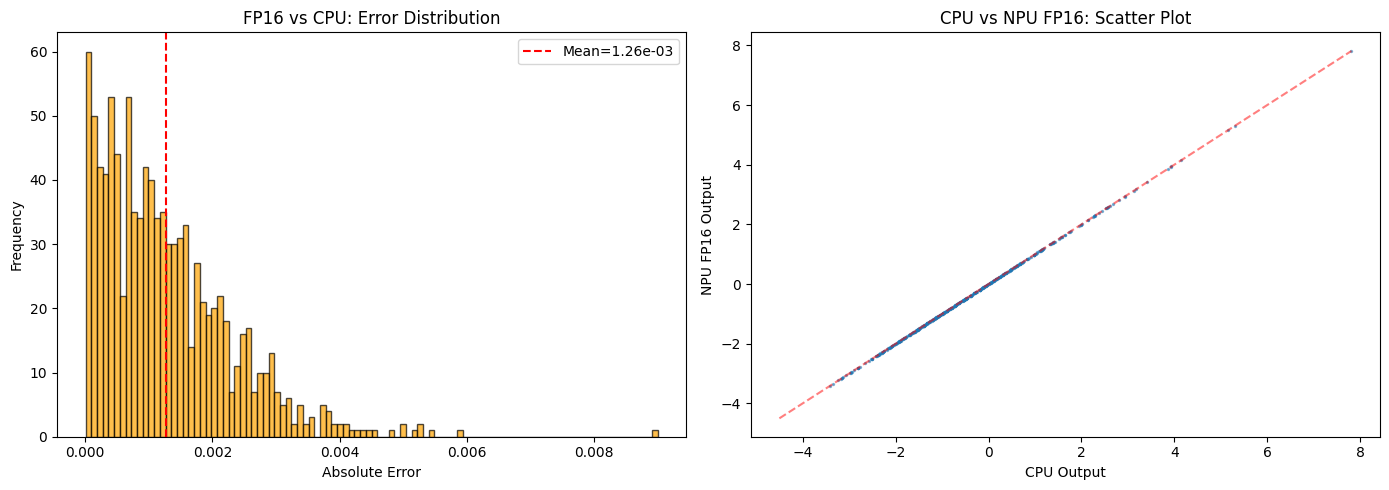

In [49]:
import matplotlib.pyplot as plt

errors_fp16 = np.abs(cpu_output.flatten() - npu_fp16_output.flatten())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 误差分布直方图
axes[0].hist(errors_fp16, bins=100, color='orange', edgecolor='black', alpha=0.7)
axes[0].set_xlabel("Absolute Error")
axes[0].set_ylabel("Frequency")
axes[0].set_title("FP16 vs CPU: Error Distribution")
axes[0].axvline(np.mean(errors_fp16), color='red', linestyle='--', label=f"Mean={np.mean(errors_fp16):.2e}")
axes[0].legend()

# 散点图：CPU vs FP16
axes[1].scatter(cpu_output.flatten()[:500], npu_fp16_output.flatten()[:500], s=2, alpha=0.5)
axes[1].plot([cpu_output.min(), cpu_output.max()], [cpu_output.min(), cpu_output.max()], 'r--', alpha=0.5)
axes[1].set_xlabel("CPU Output")
axes[1].set_ylabel("NPU FP16 Output")
axes[1].set_title("CPU vs NPU FP16: Scatter Plot")

plt.tight_layout()
plt.savefig("../images/fp16_error_analysis.png", dpi=150)
plt.show()

**预期结果与现象分析**：

FP16模式下误差通常比FP32模式大2~4个数量级，最大相对误差可能达到10⁻²~10⁻³量级。在进行大规模累加（如LayerNorm中的ReduceSum）时，如果未做混合精度保护，可能出现inf（无穷大）或NaN（非数字）值。此时需要采用混合精度策略——在累加等关键步骤将数据临时提升到FP32计算，完成后再转回FP16。

### 实验任务三：CPU-NPU数值一致性深度验证

**步骤1：使用CANN精度比对工具**

CANN提供了官方的精度比对工具（msaccucmp.py或msprobe），可系统化地比对CPU与NPU的输出结果。

```bash
# 比对FP16模式下NPU输出与CPU基准输出
python3 /usr/local/Ascend/ascend-toolkit/latest/tools/operator_cmp/compare/msaccucmp.py compare \
    -m npu_fp16_output.npy \
    -g cpu_output.npy \
    -alg 0
```

**步骤2：多精度模式综合对比矩阵**

构建一张综合对比矩阵，评估不同精度配置下的数值表现：

```python
import pandas as pd

# 定义精度指标计算函数
def compute_all_metrics(ref, target, name):
    abs_err = np.abs(ref - target)
    rel_err = np.abs(ref - target) / (np.abs(ref) + 1e-8)
    cos_sim = np.dot(ref.flatten(), target.flatten()) / (
        np.linalg.norm(ref.flatten()) * np.linalg.norm(target.flatten()) + 1e-8
    )
    mse = np.mean((ref - target) ** 2)
    return {
        "对比组": name,
        "最大绝对误差": np.max(abs_err),
        "平均绝对误差": np.mean(abs_err),
        "最大相对误差": np.max(rel_err),
        "余弦相似度": cos_sim,
        "MSE": mse
    }

# 构建对比矩阵
results = []
results.append(compute_all_metrics(cpu_output, npu_fp32, "NPU_FP32 vs CPU"))
results.append(compute_all_metrics(cpu_output, npu_fp16, "NPU_FP16 vs CPU"))
results.append(compute_all_metrics(npu_fp32, npu_fp16, "NPU_FP16 vs NPU_FP32"))

df = pd.DataFrame(results)
print("\n========== 精度对比矩阵 ==========")
print(df.to_string(index=False, float_format="%.6e"))

# 精度判定
for _, row in df.iterrows():
    if row["余弦相似度"] > 0.9999:
        print(f"✅ {row['对比组']}: 精度一致性优秀")
    elif row["余弦相似度"] > 0.99:
        print(f"⚠️ {row['对比组']}: 精度一致性可接受，建议进一步分析")
    else:
        print(f"❌ {row['对比组']}: 精度偏差较大，需排查")
```

In [50]:
import pandas as pd

# 定义精度指标计算函数
def compute_all_metrics(ref, target, name):
    abs_err = np.abs(ref - target)
    rel_err = np.abs(ref - target) / (np.abs(ref) + 1e-8)
    cos_sim = np.dot(ref.flatten(), target.flatten()) / (
        np.linalg.norm(ref.flatten()) * np.linalg.norm(target.flatten()) + 1e-8
    )
    mse = np.mean((ref - target) ** 2)
    return {
        "对比组": name,
        "最大绝对误差": np.max(abs_err),
        "平均绝对误差": np.mean(abs_err),
        "最大相对误差": np.max(rel_err),
        "余弦相似度": cos_sim,
        "MSE": mse
    }

# 构建对比矩阵
results = []
results.append(compute_all_metrics(cpu_output, npu_output, "NPU_FP32 vs CPU"))
results.append(compute_all_metrics(cpu_output, npu_fp16_output, "NPU_FP16 vs CPU"))
results.append(compute_all_metrics(npu_output, npu_fp16_output, "NPU_FP16 vs NPU_FP32"))

df = pd.DataFrame(results)
print("\n========== 精度对比矩阵 ==========")
print(df.to_string(index=False, float_format="%.6e"))

# 精度判定
for _, row in df.iterrows():
    if row["余弦相似度"] > 0.9999:
        print(f"✅ {row['对比组']}: 精度一致性优秀")
    elif row["余弦相似度"] > 0.99:
        print(f"⚠️ {row['对比组']}: 精度一致性可接受，建议进一步分析")
    else:
        print(f"❌ {row['对比组']}: 精度偏差较大，需排查")
        


========== 精度对比矩阵 ==========
                 对比组       最大绝对误差       平均绝对误差       最大相对误差        余弦相似度          MSE
     NPU_FP32 vs CPU 9.001255e-03 1.261689e-03 5.617335e-01 9.999995e-01 2.639443e-06
     NPU_FP16 vs CPU 9.001255e-03 1.261689e-03 5.617335e-01 9.999995e-01 2.639443e-06
NPU_FP16 vs NPU_FP32 0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00
✅ NPU_FP32 vs CPU: 精度一致性优秀
✅ NPU_FP16 vs CPU: 精度一致性优秀
✅ NPU_FP16 vs NPU_FP32: 精度一致性优秀


### 综合实验步骤汇总

| 步骤 | 操作 | 关键命令/API | 要点 |
|:----:|------|------------|------|
| 1 | 环境检查 | `npu-smi info`、`atc --help` | 确认CANN环境可用 |
| 2 | 准备模型与数据 | ONNX导出、NumPy生成测试数据 | 确保CPU与NPU使用相同输入 |
| 3 | 模型转换（FP32） | `atc ... --precision_mode=force_fp32` | 基准精度模式 |
| 4 | FP32推理与比对 | PyACL推理 + 对比脚本 | 预期余弦相似度 > 0.9999 |
| 5 | 模型转换（FP16） | `atc ... --precision_mode_v2=fp16` | 切换为半精度模式 |
| 6 | FP16推理与比对 | 运行FP16模型 + 三项对比分析 | 观察FP16偏差特征 |
| 7 | 误差可视化 | 直方图、散点图 | 直观理解误差分布 |
| 8 | 精度比对工具 | msaccucmp.py / msprobe | 系统性验证CPU-NPU一致性 |
| 9 | 撰写实验报告 | 记录数据、分析原因、提出优化建议 | — |

## 五、任务拓展

### 拓展1：混合精度算子开发实践

在FP16推理中，针对容易溢出的算子（如Softmax、LayerNorm），通过TBE DSL或Ascend C实现混合精度计算。

**以Softmax为例**，纯FP16实现的$y_i = e^{x_i} / \sum e^{x_j}$在输入$x_i$稍大时就会因$e^{x_i}$溢出而输出NaN。数值稳定的实现方法是先减去输入最大值：

$$y_i = \frac{e^{x_i - x_{\max}}}{\sum_j e^{x_j - x_{\max}}}$$

而在ReduceSum累加环节，同样需要将累加器提升到FP32以避免累加溢出。

### 拓展2：多算子粒度精度配置

使用`--op_precision_mode`参数为不同算子设置差异化的精度模式。例如，对矩阵乘法（MatMul）使用FP16以提升性能，对归一化（LayerNorm/Softmax）使用FP32以保证精度。

```ini
# precision_config.ini
MatMul=high_performance
LayerNorm=high_precision
SoftmaxV2=high_precision
```

```bash
atc --model=resnet50.onnx \
    --framework=5 \
    --output=resnet50_mixed \
    --soc_version=Ascend310P3 \
    --input_shape="actual_input_1:1,3,224,224" \
    --precision_mode=allow_mix_precision \
    --op_precision_mode=precision_config.ini
```

## 六、实验总结

通过本实验，同学们从理论到实践全面体验了CANN平台上单精度（FP32）与半精度（FP16）浮点运算的正确性对比。主要内容回顾如下：

**1. 浮点精度理论理解**：FP32提供约7位十进制有效精度和极大的动态范围（≈3.4×10³⁸），在数值稳定性要求高的场景下不可或缺；FP16仅提供约3位有效精度且表示上限仅为65504，在大规模累加场景下极易溢出，但其内存占用减半和计算吞吐翻倍的优势使其在推理加速场景中极具吸引力。

**2. CANN精度配置能力**：掌握了`--precision_mode`（force_fp32/force_fp16/allow_fp32_to_fp16等）、`--precision_mode_v2`（fp16/origin/cube_fp16in_fp32out）、`--op_precision_mode`（算子级.ini配置）等多层次的精度控制手段。

**3. CPU-NPU一致性验证方法论**：学会了使用绝对误差、相对误差、余弦相似度、MSE等多维度指标量化数值偏差，并利用CANN精度比对工具和Dump功能系统化地定位精度问题。在精度排查时，建议按照“先排除非精度问题 → 排查FP16精度不足 → 可视化定位偏差区间 → 分解计算过程定位根因 → 针对性优化”的流程进行。

**4. 混合精度的核心思想**：不是全量退回FP32，而是在最容易出问题的累加环节临时提升到FP32，兼顾精度与性能。这一思想贯穿CANN算子开发的始终，也是工业界混合精度训练的核心理念。

**核心收获**：

> 精度不是越高越好，性能也不是越快越好——理解浮点精度的边界，善用混合精度工具，在精度与性能之间找到最优平衡点，才是AI工程师的核心竞争力。